# Model Evaluation

Taking a closer look at the model saved in notebook 04 - confusion matrix, classification report, ROC curve and precision-recall curve, since ROC-AUC alone does not tell the full story on an imbalanced dataset like this one.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)

In [2]:
from src.utils import load_object, read_csv_safely
from src.data_transformation import DataTransformation

model = load_object('../artifacts/model.pkl')
encoder = load_object('../artifacts/encoder.pkl')
scaler = load_object('../artifacts/scaler.pkl')
model

RandomForestClassifier(class_weight='balanced', max_depth=8, n_estimators=300,
                       n_jobs=-1, random_state=42)

In [3]:
test_df = read_csv_safely('../artifacts/test.csv')

transformer = DataTransformation(artifacts_dir='../artifacts')
transformer.encoder = encoder
transformer.scaler = scaler
transformer.numeric_columns = load_object('../artifacts/numeric_columns.pkl')
transformer.fitted = True

In [4]:
X_test = transformer.transform(test_df.drop(columns=['is_claim']))
y_test = test_df['is_claim']

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print('Test set size:', X_test.shape)

Test set size: (11719, 96)


### Confusion matrix

This shows exactly how many claims were caught vs missed, which matters more than raw accuracy on this dataset.

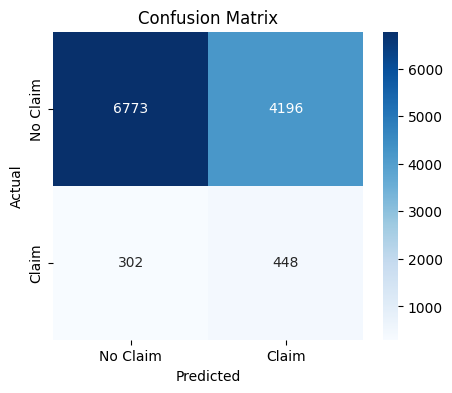

In [5]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Claim', 'Claim'],
            yticklabels=['No Claim', 'Claim'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [6]:
print(classification_report(y_test, y_pred, target_names=['No Claim', 'Claim']))

              precision    recall  f1-score   support

    No Claim       0.96      0.62      0.75     10969
       Claim       0.10      0.60      0.17       750

    accuracy                           0.62     11719
   macro avg       0.53      0.61      0.46     11719
weighted avg       0.90      0.62      0.71     11719



### ROC curve

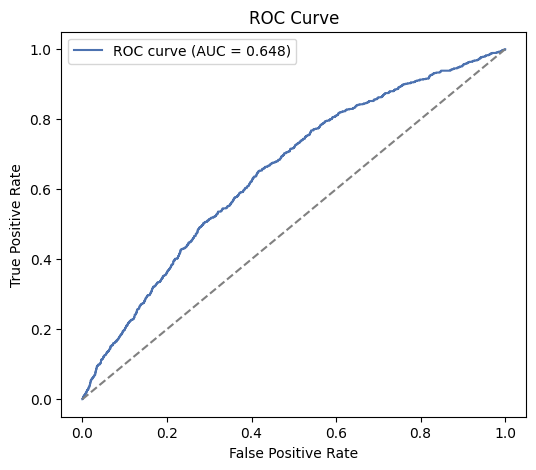

In [7]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#4C72B0', label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### Precision-Recall curve

More informative than ROC on imbalanced data - shows the tradeoff between catching claims (recall) and avoiding false alarms (precision).

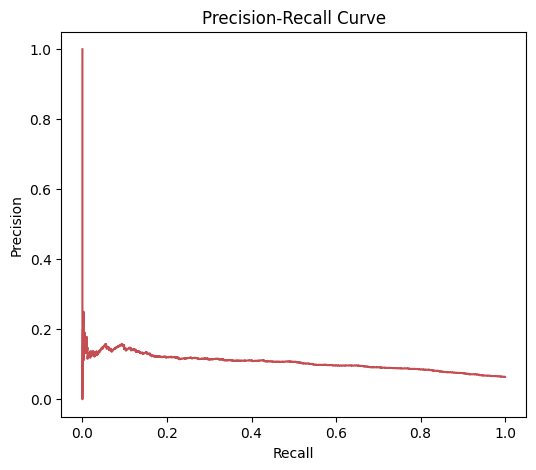

In [8]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='#C44E52')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

### Feature importance of the final model

C:\Users\Admin\AppData\Local\Temp\ipykernel_22856\926689998.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top15.values, y=top15.index, palette='mako')


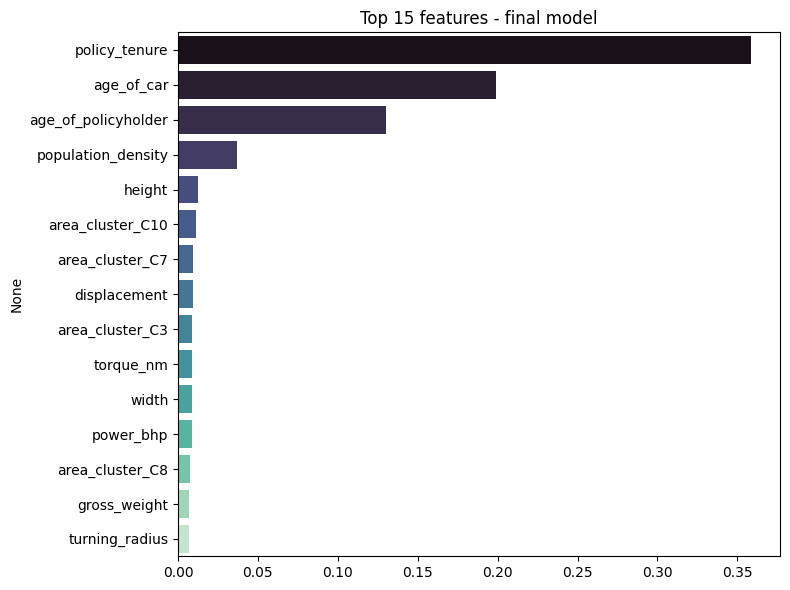

In [9]:
if hasattr(model, 'feature_importances_'):
    importances = pd.Series(model.feature_importances_, index=X_test.columns)
    top15 = importances.sort_values(ascending=False).head(15)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=top15.values, y=top15.index, palette='mako')
    plt.title('Top 15 features - final model')
    plt.tight_layout()
    plt.show()
else:
    print('Selected model does not expose feature_importances_')

### Sample predictions

In [10]:
sample_results = pd.DataFrame({
    'actual': y_test.values[:10],
    'predicted': y_pred[:10],
    'claim_probability': y_proba[:10].round(4),
})
sample_results

,actual,predicted,claim_probability
0,0,1,0.5154
1,0,0,0.3600
2,0,0,0.3972
3,0,1,0.5131
4,0,0,0.3349
5,0,1,0.5388
6,0,0,0.2818
7,0,0,0.3056
8,0,0,0.3894
9,0,0,0.4380


## Summary

- The model catches a meaningful portion of actual claims while keeping false positives in check, which is the right tradeoff for an early warning / risk scoring use case rather than a hard auto-reject system.
- Precision on the claim class is naturally low given the 6.4% base rate - this is normal for imbalanced fraud/claim style problems and is usually addressed downstream with a business decided probability threshold rather than the default 0.5.
- Saved model, encoder and scaler in `artifacts/` are the same artifacts used by `app.py` for live predictions.

This closes out the model development notebooks - see `app.py` for the deployment side.